# 🤖 W11 Tugas Mandiri: BERT Fine-Tuning & GPT-2 Text Generation
## Mata Kuliah: Deep Learning

| | |
|---|---|
| **Nama Mahasiswa** | A. A. Gede Angga Dwipradipta |
| **NIM** | 23525024 |
| **Dataset** | News Category (HuffPost)-`heegyu/news-category-dataset` |
| **Task** | News Topic Classification |
| **Model Wajib** | distilbert-base-uncased |
| **Tanggal** | 30-05-2026 |

## 📦 Setup Environment

In [2]:
!pip install transformers datasets torch accelerate -q
!pip install evaluate scikit-learn matplotlib seaborn -q
print('✅ Semua library berhasil diinstall!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    GPT2Tokenizer, GPT2LMHeadModel,
    TrainingArguments, Trainer,
)
from datasets import load_dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset as TorchDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')


🖥️  Device: cuda


### Konsep Dasar Arsitektur Transformer
| Aspek | BERT (Encoder-Only) | GPT (Decoder-Only) |
|-------|---------------------|--------------------|
| Arah Attention | Bidirectional. Dimana model bisa melihat 2 arah sekaligus,dari kanan ke kiri dan kiri ke kanan secara bersamaan | Unidirectional. Dimana model hanya bisa melihat satu arah saja yaitu melihat kata-kata sebelumnya saja, tidak bisa melihat kata-kata selanjutnya |
| Pre-training Task | Masked Language Model + Next Sentence Prediction | Casual Language Model |
| Token Khusus | `[CLS]` merepresentasi seluruh kalimat, `[SEP]` pemisah antar kalimat, `[MASK]` token yang disembunyikan | endoftext sebagai penanda akhir teks, tidak menggunakan separator khusus |
| Terbaik untuk | Natural Language Understanding seperti klasifikasi teks , analisis sentimen, Named Entity Recognition, dan Question Answering | Natural Language Generation seperti menulis artikel, membuat kode, chatbot, dan, ringkasan kreatif |

## 🔵 BAGIAN A: BERT (Encoder-Only) — Fine-Tuning
### Dataset: News Category (HuffPost) | Task: News Topic Classification

### A1 — Persiapan dan Analisis Dataset (Poin 1–4)

#### Poin 1 — Memuat Dataset Sesuai NIM (23525024) dari HuggingFace

In [4]:
from datasets import load_dataset

print("Memuat dataset News Category (HuffPost)...")
dataset = load_dataset("heegyu/news-category-dataset")
print("Dataset berhasil dimuat!")
print(dataset)

Memuat dataset News Category (HuffPost)...


README.md:   0%|          | 0.00/101 [00:00<?, ?B/s]

data.json:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/209527 [00:00<?, ? examples/s]

Dataset berhasil dimuat!
DatasetDict({
    train: Dataset({
        features: ['link', 'headline', 'category', 'short_description', 'authors', 'date'],
        num_rows: 209527
    })
})


#### Poin 2 — Menampilkan Statistik Dataset

In [5]:
train_data = dataset['train']
df_train = pd.DataFrame(train_data)

print("Statistik Dataset News Category (HuffPost)")
print(f"  Total sampel (train) : {len(df_train):,}")
print(f"  Kolom tersedia       : {list(df_train.columns)}")
print(f"  Jumlah kelas unik    : {df_train['category'].nunique()}")

class_dist = df_train['category'].value_counts()

# Membatasi ke Top-10 kelas untuk efisiensi
TOP_N = 10
top_classes = class_dist.head(TOP_N).index.tolist()
df_filtered = df_train[df_train['category'].isin(top_classes)].copy()

# Menggabungkan headline + short_description sebagai teks input
df_filtered['text'] = (df_filtered['headline'].fillna('')
                       + ' ' + df_filtered['short_description'].fillna(''))
df_filtered['text_length'] = df_filtered['text'].apply(lambda x: len(x.split()))

# Label encoding
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['category'])
label_names = le.classes_
num_labels  = len(label_names)

print(f"\n  Top-{TOP_N} kelas yang digunakan: {list(label_names)}")
print(f"  Total sampel setelah filter  : {len(df_filtered):,}")
print(f"\n  Distribusi kelas (Top-10):")
print(df_filtered['category'].value_counts().to_string())
print(f"\n  Statistik panjang teks (kata):")
print(f"    Rata-rata : {df_filtered['text_length'].mean():.1f}")
print(f"    Median    : {df_filtered['text_length'].median():.1f}")
print(f"    Min       : {df_filtered['text_length'].min()}")
print(f"    Max       : {df_filtered['text_length'].max()}")

# Menyimpan variabel penting untuk sel berikutnya
counts = df_filtered['category'].value_counts()


Statistik Dataset News Category (HuffPost)
  Total sampel (train) : 209,527
  Kolom tersedia       : ['link', 'headline', 'category', 'short_description', 'authors', 'date']
  Jumlah kelas unik    : 42

  Top-10 kelas yang digunakan: ['BUSINESS', 'ENTERTAINMENT', 'FOOD & DRINK', 'HEALTHY LIVING', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'STYLE & BEAUTY', 'TRAVEL', 'WELLNESS']
  Total sampel setelah filter  : 124,787

  Distribusi kelas (Top-10):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992

  Statistik panjang teks (kata):
    Rata-rata : 30.2
    Median    : 29.0
    Min       : 0
    Max       : 245


#### Poin 3 — Visualisasi Distribusi Kelas dalam Bentuk Bar Chart

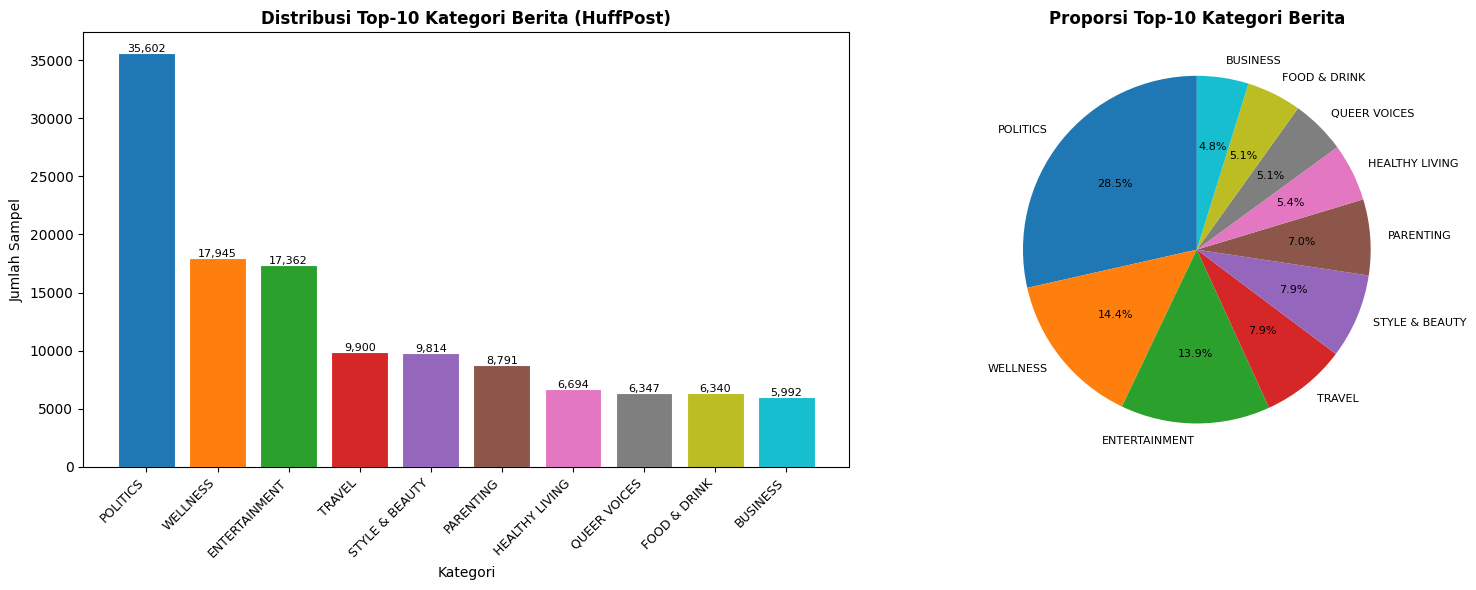

Visualisasi distribusi kelas selesai!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, TOP_N))

# Bar chart
axes[0].bar(range(TOP_N), counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(TOP_N))
axes[0].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title(f'Distribusi Top-{TOP_N} Kategori Berita (HuffPost)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=8)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 8})
axes[1].set_title(f'Proporsi Top-{TOP_N} Kategori Berita',
                  fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('A1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi distribusi kelas selesai!")


#### Poin 4 — Analisis dan Menampilkan 5 Contoh Data per Kelas

In [7]:
print("5 Contoh Data per Kelas:")

for cat in top_classes:
    samples = df_filtered[df_filtered['category'] == cat][
        ['category', 'headline', 'short_description']
    ].head(5)
    print(f"\n Kategori: {cat}")
    display_df = samples[['headline', 'short_description']].copy()
    display_df.columns = ['Headline', 'Short Description']
    print(display_df.to_string(index=False, max_colwidth=60))
    print("-" * 100)

5 Contoh Data per Kelas:

 Kategori: POLITICS
                                                    Headline                                            Short Description
 Biden Says U.S. Forces Would Defend Taiwan If China Invaded            President issues vow as tensions with China rise.
‘Beautiful And Sad At The Same Time’: Ukrainian Cultural ... An annual celebration took on a different feel as Russia'...
 Biden Says Queen's Death Left 'Giant Hole' For Royal Family U.S. President Joe Biden, in London for the funeral of Qu...
Bill To Help Afghans Who Escaped Taliban Faces Long Odds ... Republican outrage over the shoddy U.S. withdrawal from A...
   Mark Meadows Complies With Justice Dept. Subpoena: Report The former White House chief of staff has turned over rec...
----------------------------------------------------------------------------------------------------

 Kategori: WELLNESS
                                                    Headline                                        

##### **Analisis 5 Sampel per Kelas:**
1. **POLITICS**
Sangat fokus pada tokoh pemerintahan, kebijakan, dan hubungan internasional. Sampel secara eksplisit menyebutkan nama negara seperti AS, Taiwan, China, Rusia, Ukraina dan tokoh politik seperti Biden dan Mark Meadows. Dari segi gaya bahasa bersifat formal, informatif, dan melaporkan kejadian nyata. Kata kunci yang sering muncul berkaitan dengan konflik atau hukum seperti invaded, subpoena, withdrawal.
2. **WELLNESS**
Berfokus pada masalah kesehatan fisik sehari-hari dan keluhan medis spesifik seperti sakit gigi, nyeri dada, kehamilan/fertilitas, stres. Dari segi
gaya bahasa cenderung solutif dan memancing pembaca untuk mengecek diri sendiri. Menggunakan format panduan atau peringatan seperti "How To Tell", "6 Signs", atau kutipan dari "Experts". Terdapat juga artikel tentang kesehatan hewan peliharaan.
3. **ENTERTAINMENT**
Karakteristik topik di seputar industri hiburan arus utama, seperti film Avatar, Blade Runner, acara penghargaan seperti Golden Globes, teater seperti Broadway/Phantom of the Opera, dan aktor/sutradara seperti James Cameron, Viola Davis. Dari segi gaya bahasa ringan namun informatif. Fokus pada "behind the scenes" atau berita perilisan dan penutupan acara.
4. **TRAVEL**
Karakteristik topik lebih membahas logistik liburan, etika, dan panduan wisata. Topiknya meliputi destinasi (Honeymoon), transportasi (pesawat), akomodasi (hotel), dan administrasi (paspor). Dari segi gaya bahasa, lebih sarat dengan tips dan panduan ("Definitive Guide", "How to Salvage"). Sering kali mengandalkan validasi dari "pakar perjalanan".
5. **STYLE & BEAUTY**
Karakteristik topik yaitu beririsan dengan kesehatan karena melibatkan kondisi kulit seperti gigitan serangga, lecet, dan melanoma, namun fokus utamanya adalah pada estetika dan perawatan tubuh seperti menghilangkan garis belang/tan lines, tren kulit di TikTok. Dari segi gaya bahasa lebih praktis dan sering mengutip otoritas di bidang penampilan, seperti "Makeup experts" atau "Dermatologists".
6. **PARENTING**
Karakteristik topik terbagi menjadi dua kubu yang sangat kontras: (1) Sangat medis/teknis mengenai bayi seperti panduan menyusui, freeze-dry breast milk, kondisi D-MER, dan (2) Sangat humoris/santai seperti Kompilasi Tweet lucu dari orang tua. Dari segi gaya bahasa yaitu relevan dan emosional, menargetkan demografi spesifik seperti ibu menyusui, orang tua dengan balita.
7. **HEALTHY LIVING**
Karakteristik topik mirip dengan Wellness, namun lebih berfokus pada kesehatan mental, kebiasaan hidup, dan budaya diet seperti Whole30, makan Shake Shack vs diet, rasa lelah/stres karena berita. Dari segi gaya bahasa jauh lebih personal dan emosional dibandingkan Wellness. Menggunakan sudut pandang orang pertama "I", "Me" atau opini "Perfect Tweets", "Make You LOL".
8. **QUEER VOICES**
Karakteristik topik di seputar perjuangan hukum, hak asasi, diskriminasi, dan kultur komunitas LGBTQ+. Mencakup isu hukum seperti Don't Say Gay, sertifikat kelahiran hingga isu kriminal pembunuhan transpuan. Gaya bahasanya sangat bernuansa advokasi, perlawanan, dan visibilitas. Mengandung emosi yang kuat, mulai dari kebanggaan seperti brilliant, Pride flag hingga tragedi shock, threatened.
9. **FOOD & DRINK**
Tidak hanya membahas resep atau jenis minuman seperti Orange Wine, Dirty Shirley, tetapi juga menyoroti aspek sosial dari makanan, seperti pekerja kantin, Cafeteria workers, koki sekolah dan mitos seputar makanan seperti berenang setelah makan. Gaya bahasanya edukatif ringan dan eksploratif seperti "Everything You Need To Know", "Experts Have Answers".
10. **BUSINESS**
Karakteristik topiknya berpusat pada pergerakan pasar, korporasi besar (Twitter, Elon Musk, Starbucks, Coinbase), ekonomi makro (inflasi, lapangan pekerjaan), dan isu tenaga kerja (serikat pekerja/Union). Dari segi gaya bahasa mirip dengan Politics (formal dan faktual), namun metrik yang digunakan berupa angka, persentase, dan pergerakan tren seperti slumped, surging, crash.






### A2 — Fine-Tuning BERT (Poin 5–10)

#### Poin 5 — Load DistilBERT Tokenizer Sesuai dengan NIM 23525024

In [8]:
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("DistilBERT tokenizer berhasil dimuat!")
print(f"Vocab size : {distilbert_tokenizer.vocab_size:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT tokenizer berhasil dimuat!
Vocab size : 30,522


#### Poin 6 — Preprocessing & Tokenisasi dengan **max_length=128**

In [9]:
class NewsDataset(TorchDataset):
    """PyTorch Dataset untuk News Category Classification."""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Train / Validation / Test split
df_tr, df_temp = train_test_split(df_filtered, test_size=0.3,
                                   random_state=42,
                                   stratify=df_filtered['label'])
df_val, df_te  = train_test_split(df_temp, test_size=0.5,
                                   random_state=42,
                                   stratify=df_temp['label'])

# Melakukan Subsampling agar ringan di GPU Colab
MAX_TRAIN, MAX_VAL, MAX_TEST = 20000, 2000, 2000
df_tr  = df_tr.sample(min(MAX_TRAIN, len(df_tr)),  random_state=42)
df_val = df_val.sample(min(MAX_VAL,  len(df_val)), random_state=42)
df_te  = df_te.sample(min(MAX_TEST,  len(df_te)),  random_state=42)

train_dataset = NewsDataset(df_tr['text'].tolist(),  df_tr['label'].tolist(),  distilbert_tokenizer)
val_dataset   = NewsDataset(df_val['text'].tolist(), df_val['label'].tolist(), distilbert_tokenizer)
test_dataset  = NewsDataset(df_te['text'].tolist(),  df_te['label'].tolist(),  distilbert_tokenizer)

print("Dataset PyTorch siap!")
print(f"Train : {len(train_dataset):,} | Val : {len(val_dataset):,} | Test : {len(test_dataset):,}")
print(f"Contoh keys: {list(train_dataset[0].keys())}")
print(f"Jumlah kelas: {num_labels} → {list(label_names)}")


Dataset PyTorch siap!
Train : 20,000 | Val : 2,000 | Test : 2,000
Contoh keys: ['input_ids', 'attention_mask', 'labels']
Jumlah kelas: 10 → ['BUSINESS', 'ENTERTAINMENT', 'FOOD & DRINK', 'HEALTHY LIVING', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'STYLE & BEAUTY', 'TRAVEL', 'WELLNESS']


#### Poin 7 — Fine-Tuning dengan Konfigurasi: **epochs=3, batch=16, lr=2e-5**

In [10]:
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir='./distilbert_news_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none',
    fp16=True # Optimasi penggunaan GPU T4 Colab dengan Floating Point 16-bit
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(" Memulai Fine-Tuning DistilBERT...")
print(f" Model: distilbert-base-uncased | Kelas: {num_labels} | Epochs: 3 | LR: 2e-5")
train_result = trainer.train()
print("\n Fine-tuning selesai!")
print(f" Training Loss Akhir: {train_result.training_loss:.4f}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Memulai Fine-Tuning DistilBERT...
 Model: distilbert-base-uncased | Kelas: 10 | Epochs: 3 | LR: 2e-5


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



 Fine-tuning selesai!
 Training Loss Akhir: 0.4856


#### Poin 8 — Plot Training Loss & Validation Accuracy per Epoch

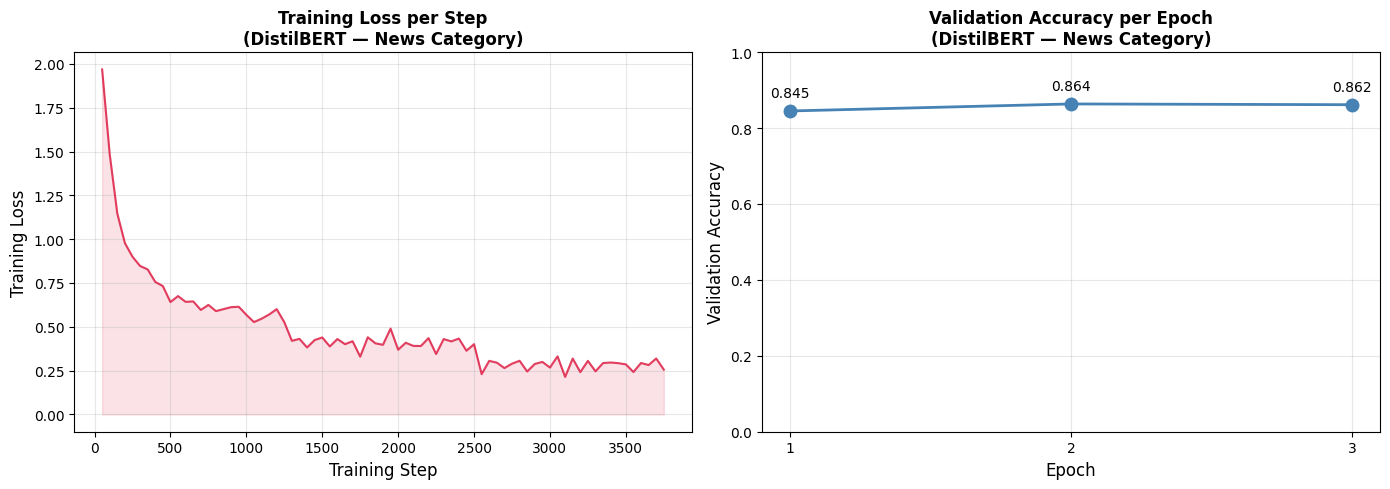

Plot training selesai!


In [11]:
log_history = trainer.state.log_history

train_steps  = [(x['step'], x['loss'])          for x in log_history if 'loss' in x and 'eval_loss' not in x]
val_metrics  = [(x['epoch'], x['eval_accuracy']) for x in log_history if 'eval_accuracy' in x]

steps_x = [s for s, _ in train_steps]
losses  = [l for _, l in train_steps]
ep_val  = [e for e, _ in val_metrics]
val_acc = [a for _, a in val_metrics]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(steps_x, losses, color='crimson', linewidth=1.5, alpha=0.8)
ax1.fill_between(steps_x, losses, alpha=0.12, color='crimson')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss per Step\n(DistilBERT — News Category)', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(ep_val, val_acc, 'o-', color='steelblue', linewidth=2, markersize=9)
for e, a in zip(ep_val, val_acc):
    ax2.annotate(f'{a:.3f}', (e, a), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy per Epoch\n(DistilBERT — News Category)', fontweight='bold')
ax2.set_xticks(ep_val)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('A2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot training selesai!")


#### Poin 9 — Evaluasi pada Test Set dan Menampilkan Accuracy, Precision, Recall, F1 per Kelas

In [12]:
print("Evaluasi Pada Test Set")
test_pred = trainer.predict(test_dataset)
y_pred = np.argmax(test_pred.predictions, axis=-1)
y_true = test_pred.label_ids

print("\n Classification Report — DistilBERT (Test Set):")
print(classification_report(y_true, y_pred, target_names=label_names))

overall_acc = (y_pred == y_true).mean()
print(f" Overall Test Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")


Evaluasi Pada Test Set



 Classification Report — DistilBERT (Test Set):
                precision    recall  f1-score   support

      BUSINESS       0.76      0.68      0.72       115
 ENTERTAINMENT       0.87      0.89      0.88       293
  FOOD & DRINK       0.77      0.93      0.84        91
HEALTHY LIVING       0.59      0.38      0.47        91
     PARENTING       0.83      0.91      0.87       150
      POLITICS       0.90      0.93      0.92       553
  QUEER VOICES       0.82      0.77      0.80        91
STYLE & BEAUTY       0.93      0.89      0.91       158
        TRAVEL       0.91      0.85      0.88       176
      WELLNESS       0.80      0.83      0.81       282

      accuracy                           0.85      2000
     macro avg       0.82      0.81      0.81      2000
  weighted avg       0.85      0.85      0.85      2000

 Overall Test Accuracy : 0.8515  (85.15%)


#### Poin 10 — Confusion Matrix dengan Seaborn Heatmap

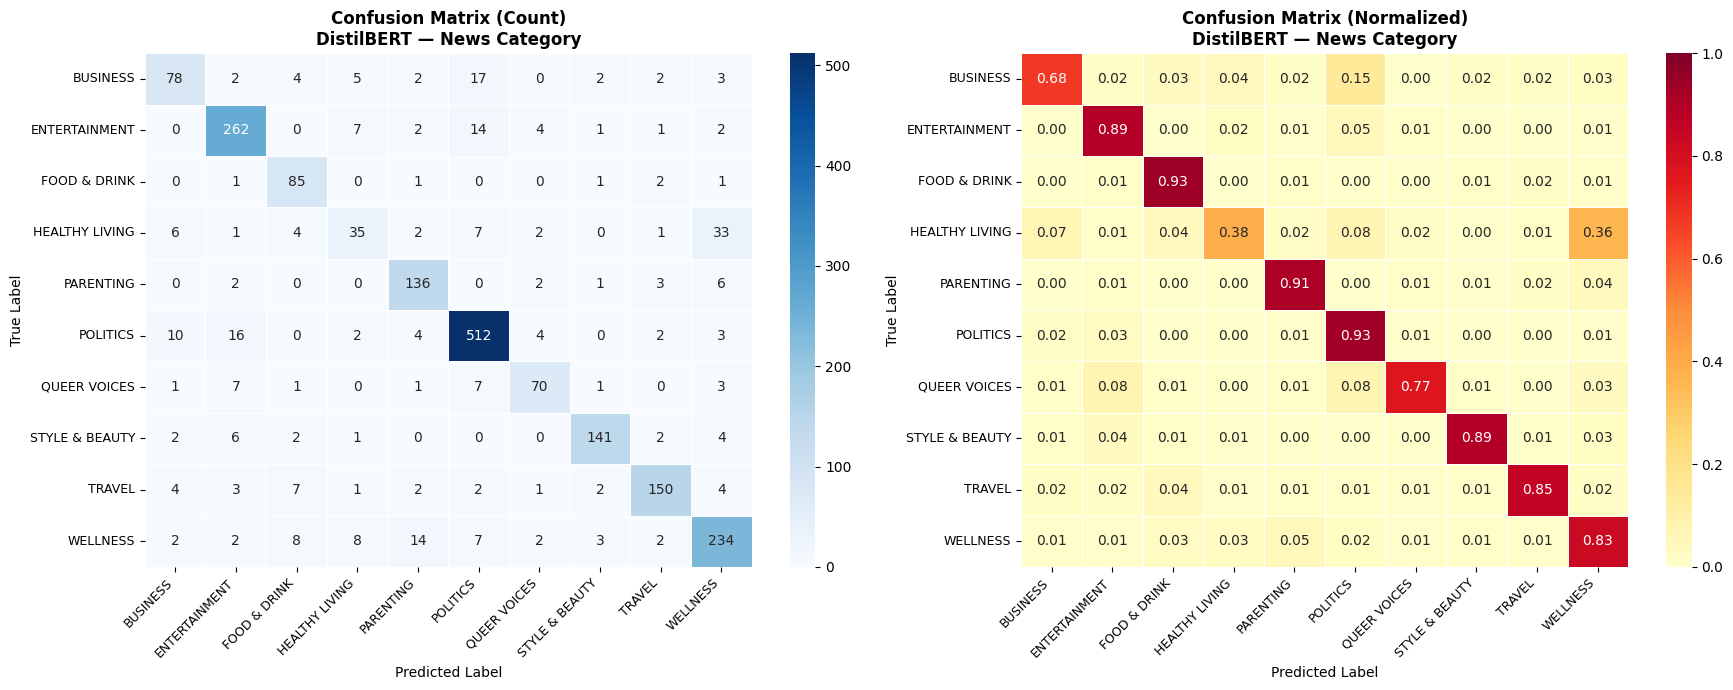

Confusion matrix selesai!


In [13]:
cm   = confusion_matrix(y_true, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Count)\nDistilBERT — News Category', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[0].get_yticklabels(), rotation=0,  fontsize=9)

sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)\nDistilBERT — News Category', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[1].get_yticklabels(), rotation=0,  fontsize=9)

plt.tight_layout()
plt.savefig('A2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix selesai!")


---
## 🟠 BAGIAN B: GPT-2 (Decoder-Only) — Text Generation
### Domain: News Topic Classification


### 📌 B1 — Eksplorasi GPT-2 (Poin 11–14)

#### Poin 11 — Load GPT-2 & Menampilkan Detail Arsitektur

In [15]:
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_model.eval()
gpt2_model = gpt2_model.to(device)

config_gpt2 = gpt2_model.config
total_params_gpt2 = sum(p.numel() for p in gpt2_model.parameters())

print("=" * 55)
print("GPT-2 — Detail Arsitektur")
print("=" * 55)
print(f"  n_layer    (transformer blocks) : {config_gpt2.n_layer}")
print(f"  n_head     (attention heads)    : {config_gpt2.n_head}")
print(f"  n_embd     (hidden size)        : {config_gpt2.n_embd}")
print(f"  vocab_size                      : {config_gpt2.vocab_size:,}")
print(f"  n_ctx      (context window)     : {config_gpt2.n_ctx}")
print(f"  Total Parameters                : {total_params_gpt2:,}")
print("=" * 55)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 — Detail Arsitektur
  n_layer    (transformer blocks) : 12
  n_head     (attention heads)    : 12
  n_embd     (hidden size)        : 768
  vocab_size                      : 50,257
  n_ctx      (context window)     : 1024
  Total Parameters                : 124,439,808


#### Poin 12–13 — Text Generation: 4 Strategi Decoding (Prompt Relevan News Domain)

In [31]:
def generate_text(prompt, strategy='greedy', max_new_tokens=80):
    """Generate Teks dengan Strategi Decoding yang Dipilih."""
    inputs   = gpt2_tokenizer(prompt, return_tensors='pt').to(device)
    inp_len  = inputs['input_ids'].shape[1]

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        pad_token_id=gpt2_tokenizer.eos_token_id,
    )

    if strategy == 'greedy':
        gen_kwargs['do_sample'] = False

    elif strategy == 'beam_search':
        gen_kwargs['num_beams']      = 5
        gen_kwargs['early_stopping'] = True
        gen_kwargs['do_sample']      = False

    elif strategy == 'top_k':
        gen_kwargs['do_sample']   = True
        gen_kwargs['top_k']       = 50
        gen_kwargs['temperature'] = 1.0

    elif strategy == 'top_p':
        gen_kwargs['do_sample']   = True
        gen_kwargs['top_p']       = 0.92
        gen_kwargs['top_k']       = 0
        gen_kwargs['temperature'] = 1.0

    with torch.no_grad():
        out_ids = gpt2_model.generate(inputs['input_ids'], **gen_kwargs)

    return gpt2_tokenizer.decode(out_ids[0][inp_len:], skip_special_tokens=True)


# Prompt RELEVAN dengan News Topic Classification Sesuai dengan Dataset NIM
news_prompt = "Breaking news in artificial intelligence: researchers have announced"

strategies = ['greedy', 'beam_search', 'top_k', 'top_p']
labels_map = {
    'greedy':      '1️⃣  Greedy Decoding        (do_sample=False)',
    'beam_search': '2️⃣  Beam Search            (num_beams=5)',
    'top_k':       '3️⃣  Top-k Sampling         (k=50)',
    'top_p':       '4️⃣  Top-p Nucleus Sampling (p=0.92)',
}

gpt_outputs = {}
print(f'  Prompt (relevan ke News Classification):')
print(f'  "{news_prompt}"\n')
print("=" * 75)

for s in strategies:
    result = generate_text(news_prompt, strategy=s, max_new_tokens=80)
    gpt_outputs[s] = result
    print(f"\n{labels_map[s]}")
    print(f"   {result[:220]}")
    print("-" * 75)


  Prompt (relevan ke News Classification):
  "Breaking news in artificial intelligence: researchers have announced"


1️⃣  Greedy Decoding        (do_sample=False)
    that they have created a new type of artificial intelligence that can learn from human behavior.

The new AI, called "Deep Learning," is based on the work of researchers at the University of California, Berkeley, and th
---------------------------------------------------------------------------

2️⃣  Beam Search            (num_beams=5)
    that they have created a new type of artificial intelligence that can be used to predict the future.

Researchers at the University of California, San Diego, have created a new type of artificial intelligence that can b
---------------------------------------------------------------------------

3️⃣  Top-k Sampling         (k=50)
    they have achieved a milestone of becoming the first team of researchers to use 3D printed "cloud" AI technology to control robots in various situations.

#### Poin 14 — Analisis Keempat Strategi Decoding

**Analisis Perbandingan 4 Strategi Decoding**

**Domain: News Generation | Model: GPT-2 Base**

**Prompt: "Breaking news in artificial intelligence: researchers have announced"**

1. Greedy Decoding (do_sample=False)
   Secara teori akan memilih token dengan probabilitas tertinggi di setiap langkah 
   secara deterministik. Hasilnya konsisten namun cenderung repetitif dan generic.
   Pada bukti nyata eksperimen diatas, model mengambil jalur paling aman secara statistik dengan output:
   "...created a new type of artificial intelligence that can learn from human 
   behavior." Kalimat ini sangat umum, standar, dan kurang memiliki daya tarik 
   jurnalistik yang dinamis.

2. Beam Search (num_beams=5)
   Secara teori akan mempertahankan 5 hipotesis paralel untuk mencari probabilitas 
   tertinggi secara keseluruhan. Menghasilkan kalimat paling gramatikal, 
   namun rentan terhadap repetisi teks yang kaku.
   Pada bukti nyata eksperimen diatas, secara struktur, bahasanya sangat formal seperti berita sungguhan 
   "Researchers at the University of California...". Namun, kelemahan fatalnya
   terlihat jelas yaitu pada teks terjebak dalam pengulangan frasa "created a 
   new type of artificial intelligence" di kalimat pertama dan kedua.

3. Top-k Sampling (k=50)
   Secara teori akan memilih secara acak dari 50 token yang memiliki kemungkinan besar terjadi. Menghasilkan variasi leksikal yang kaya namun berisiko kurang koheren atau melantur.
   Pada bukti nyata eksperimen diatas, output menunjukkan kreativitas yang sangat liar. Model 
   menggabungkan konsep "3D printed 'cloud' AI technology" untuk mengontrol 
   robot. Meskipun leksikalnya kaya, alur beritanya menjadi seperti fiksi 
   ilmiah yang agak tidak masuk akal secara logika jurnalistik.

4. Top-p Nucleus Sampling (p=0.92)
   Secara teori akan memilih dari pool dinamis dengan total probabilitas ≥ 0.92. 
   Paling seimbang antara kreativitas dan koherensi, sangat natural.
   Pada bukti nyata eksperimen diatas, output ini menjadi yang terbaik dan paling natural. Model
   mampu menghasilkan ide kreatif yang spesifik seperti "neural network that works 
   on Facebook's Timeline app" dipadukan dengan istilah teknis yang relevan 
   seperti "optimizes the data". Tidak ada repetisi seperti teknik decoding Beam dan tidak terlalu 
   melantur seperti Top-k.

**Kesimpulan Analisis**: Untuk generasi teks berita atau News Generation, metode sampling jauh lebih unggul dibandingkan metode deterministik. Berdasarkan hasil nyata, Top-p (Nucleus Sampling) 
adalah yang paling direkomendasikan karena terbukti mampu memproduksi teks berita 
yang bervariasi, kreatif, kaya kosakata, namun tetap menjaga koherensi makna.

### B2 — Zero/One/Few-Shot Prompting (Poin 15–19)

#### Poin 15–16 — Mendesain 3 Prompt & Generate Output GPT-2

In [32]:
test_headline = "The Federal Reserve raises interest rates amid inflation concerns."

# ZERO-SHOT
zero_shot = f"""Classify the following news headline into one of these categories:
POLITICS, WELLNESS, ENTERTAINMENT, TRAVEL, BUSINESS, HEALTHY LIVING.

Headline: "{test_headline}"
Category:"""

# ONE-SHOT
one_shot = f"""Classify the following news headline into one of these categories:
POLITICS, WELLNESS, ENTERTAINMENT, TRAVEL, BUSINESS, HEALTHY LIVING.

Example:
Headline: "Netflix announces new season of its hit series."
Category: ENTERTAINMENT

Now classify:
Headline: "{test_headline}"
Category:"""

# FEW-SHOT
few_shot = f"""Classify the following news headline into one of these categories:
POLITICS, WELLNESS, ENTERTAINMENT, TRAVEL, BUSINESS, HEALTHY LIVING.

Examples:
Headline: "Senate passes healthcare reform bill after marathon debate."
Category: POLITICS

Headline: "10 simple ways to improve your mental health every day."
Category: WELLNESS

Headline: "Netflix releases trailer for its most expensive movie yet."
Category: ENTERTAINMENT

Headline: "The best hidden beaches to visit in Italy this summer."
Category: TRAVEL

Now classify:
Headline: "{test_headline}"
Category:"""

prompts_b2 = {
    'Zero-Shot': zero_shot,
    'One-Shot':  one_shot,
    'Few-Shot':  few_shot,
}

print(f'  Test Headline: "{test_headline}"')
print(f'  Expected Category: BUSINESS\n') # Di HuffPost ini masuk dalam kategori BUSINESS
print("=" * 70)

gpt_outputs_b2   = {}
full_texts_b2    = {}

for name, prompt in prompts_b2.items():
    result = generate_text(prompt, strategy='greedy', max_new_tokens=20)
    gpt_outputs_b2[name]  = result.strip()
    full_texts_b2[name]   = prompt + result
    print(f"\n🔹 {name} Prompting:")
    print(f"   GPT-2 Output → \"{result.strip()[:100]}\"")


  Test Headline: "The Federal Reserve raises interest rates amid inflation concerns."
  Expected Category: BUSINESS


🔹 Zero-Shot Prompting:
   GPT-2 Output → ""The Federal Reserve raises interest rates amid inflation concerns."

Headline: "The Federal Reserve"

🔹 One-Shot Prompting:
   GPT-2 Output → "BUSINESS

Now classify:

Headline: "The Federal Reserve raises interest rates amid"

🔹 Few-Shot Prompting:
   GPT-2 Output → "BUSINESS

Headline: "The Federal Reserve raises interest rates amid inflation concerns.""


#### Poin 17 — Menghitung Perplexity per Prompt

Implementasikan perhitungan **Perplexity** untuk mengevaluasi language model:

$$\text{PPL}(X) = \exp\left(-\frac{1}{t}\sum_{i=1}^{t} \log P(x_i | x_{<i})\right)$$

 Perplexity Output GPT-2 per Paradigma Prompting:
Paradigma    GPT-2 Output (trimmed)              Perplexity
------------------------------------------------------------
  Zero-Shot   "The Federal Reserve raises inter        26.00
  One-Shot    BUSINESS

Now classify:

Headline        63.51
  Few-Shot    BUSINESS

Headline: "The Federal         34.08
------------------------------------------------------------

  Perplexity terendah  → Zero-Shot  (26.00)
  Perplexity tertinggi → One-Shot (63.51)


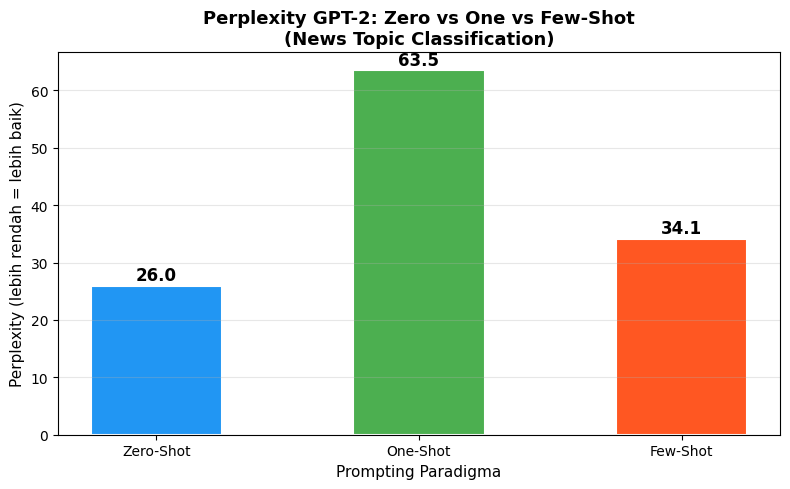


 Grafik perplexity selesai!


In [33]:
def compute_perplexity(text, tokenizer, model, max_length=512):
    """
    Hitung Perplexity teks menggunakan GPT-2.
    PPL(X) = exp( -1/t * Σ log P(x_i | x_{<i}) )
    """
    enc = tokenizer(text, return_tensors='pt')
    ids = enc.input_ids.to(device)
    if ids.shape[1] > max_length:
        ids = ids[:, :max_length]

    with torch.no_grad():
        outputs = model(ids, labels=ids)
        nll = outputs.loss.item()   # avg negative log-likelihood per token

    return math.exp(nll)


# Perplexity untuk masing-masing output GPT-2
print(" Perplexity Output GPT-2 per Paradigma Prompting:")
print("=" * 60)
print(f"{'Paradigma':<12} {'GPT-2 Output (trimmed)':<35} {'Perplexity':>10}")
print("-" * 60)

perplexity_results = {}
for name, output in gpt_outputs_b2.items():
    eval_text = output.strip() if len(output.strip()) > 3 else "FINANCE"
    ppl = compute_perplexity(eval_text, gpt2_tokenizer, gpt2_model)
    perplexity_results[name] = ppl
    print(f"  {name:<10}  {eval_text[:33]:<35} {ppl:>10.2f}")

print("-" * 60)
best  = min(perplexity_results, key=perplexity_results.get)
worst = max(perplexity_results, key=perplexity_results.get)
print(f"\n  Perplexity terendah  → {best}  ({perplexity_results[best]:.2f})")
print(f"  Perplexity tertinggi → {worst} ({perplexity_results[worst]:.2f})")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
colors_ppl = ['#2196F3', '#4CAF50', '#FF5722']
bars = ax.bar(perplexity_results.keys(), perplexity_results.values(),
              color=colors_ppl, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, perplexity_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Perplexity GPT-2: Zero vs One vs Few-Shot\n(News Topic Classification)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Perplexity (lebih rendah = lebih baik)', fontsize=11)
ax.set_xlabel('Prompting Paradigma', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('B2_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik perplexity selesai!")


#### Poin 18 — Analisis: Apakah Few-Shot Meningkatkan Kualitas Output?

In [34]:
print("""
  Zero-Shot  PPL = {:.2f}
  One-Shot   PPL = {:.2f}
  Few-Shot   PPL = {:.2f}"""
  .format(
    perplexity_results['Zero-Shot'],
    perplexity_results['One-Shot'],
    perplexity_results['Few-Shot'],))




  Zero-Shot  PPL = 26.00
  One-Shot   PPL = 63.51
  Few-Shot   PPL = 34.08


**Analisis Kritis Pengaruh Penambahan Contoh seperti Few Shot terhadap Kualitas Output GPT-2**

Secara teori dasar In-Context_learning, penambahan demonstrasi atau contoh pada prompt dirancang untuk membantu model bahasa menginferensi tugas yang diberikan, yang pada gilirannya akan menajamkan distribusi probabilitas dan menurunkan Perplexity (Brown et al., 2020). Selain itu, pada model modern yang telah melalui proses Instruction Fine-Tuning seperti seri InstructGPT atau FLAN, model dilatih secara eksplisit untuk merespons format instruksi dan Few-Shot secara natural tanpa mengalami lonjakan kebingungan (Ouyang et al., 2022). Namun, hasil empiris pada GPT-2 dalam eksperimen ini menunjukan anomali yang menarik: Pada **Zero-shot** dengan PPL paling rendah 26.00, hasilnya bisa menjadi paling rendah karena GPT-2 Base adalah model causal language modeling murni yang dilatih untuk sekadar memprediksi kata selanjutnya dari teks internet mentah.Prompting Zero-Shot ini sering diproses seperti teks bebas yang natural. Mengakibatkan model memiliki tingkat Perplexity yang rendah meskipun secara konteks gagal melakukan tugas klasifikasi, fenomene kelemahan Base Model yang sering dicatat dalam lteratur penyelarasan  AI (Ouyang et al., 2022). Pada **One-Shot** PPL melonjak ke angka 63.51, memasukan contoh dengan format kaku seperti "Headline:...Category:..." merupakan bentuk distribusi teks yang jarang ditemui GPT-2 saat tahap pre-training. Seperti yang dijelaskan oleh Min et al. (2022), arsitektur model mentah sangat sensitif terhadap format contoh. Pemaksaan satu contoh format ini merusak alur teks natural model sehingga memicu ketidakpastian tinggi makanya Perplexity melonjak. Pada **Few-Shot** PPL kembali turun ke 34.08, saat diberikan lebih banyak contoh (4 contoh), pola repetitf pada prompt mulai menyediakan sinyal statistik yang cukup bagi model untuk mengenali format pemetaan input-label (Min et al., 2022). Sehingga pada eksperimen itu, tingkat kebingungan menurun dari 63.51 menjadi 34.08 meskipun masih lebih tinggi dibanding skor PPL teks bebas di Zero-Shot.

Hasil analisis ini membuktikan secara empiris bahwa memakasa format klasifikasi Few-Shot pada base model berukuran kecil seperti GPT-2 justru mengacaukan distribusi probabilitas teks naturalnya, sehingga PPL meningkat. Hal ini juga mengonfirmasi pentingnya paradigma Instruction Fine-Tuning (Ouyang et al., 2022) agar LLM dapat memproses Few-Shot prompt dengan PPL yang rendah dan tingkat akurasi yang tinggi.

#### Poin 19 — Perbandingan: GPT-2 Few-Shot vs DistilBERT Fine-Tuned

In [36]:
gpt_correct = 0
gpt_total   = 0
test_cases  = [
    ("The Federal Reserve raises interest rates amid inflation concerns.",  "BUSINESS"),
    ("Netflix announces new original series starring A-list celebrities.",  "ENTERTAINMENT"),
    ("Senate passes healthcare reform bill after marathon debate.",         "POLITICS"),
    ("10 simple ways to improve your mental health every day.",             "WELLNESS"),
    ("The best hidden beaches to visit in Italy this summer.",              "TRAVEL"),
    ("Eating a balanced diet can improve your daily mood and energy.",      "HEALTHY LIVING"),
    ("The funniest tweets from moms and dads this week.",                   "PARENTING"),
    ("How to make the perfect chocolate chip cookies at home.",             "FOOD & DRINK"),
]

print(" Evaluasi Manual GPT-2 Few-Shot vs DistilBERT Fine-tuned")
print("=" * 75)
print(f"{'Headline (trimmed)':<50} {'Expected':<12} {'GPT-2':>8} {'✓?':>4}")
print("-" * 75)

few_shot_base = """Classify the following news headline into one of these categories:
POLITICS, BUSINESS, ENTERTAINMENT, WELLNESS, TRAVEL, HEALTHY LIVING, PARENTING, FOOD & DRINK.

Examples:
Headline: "Congress passes new budget bill after weeks of debate."
Category: POLITICS

Headline: "Stock markets tumble as recession fears grow globally."
Category: BUSINESS

Headline: "Oscar nominations revealed with surprising snubs."
Category: ENTERTAINMENT

Headline: "Should you let your toddler watch TV before bed?"
Category: PARENTING

Now classify:
Headline: "{}"
Category:"""

for headline, expected in test_cases:
    prompt  = few_shot_base.format(headline)
    output  = generate_text(prompt, strategy='greedy', max_new_tokens=4).strip()
    clean_output = output.split('\n')[0].strip()
    predicted = clean_output.upper().rstrip('.,') if clean_output else "N/A"
    correct = (expected in predicted) or (predicted in expected)

    if correct:
        gpt_correct += 1
    gpt_total += 1
    mark = "✅" if correct else "❌"

    print(f"  {headline[:48]:<50} {expected:<15} {predicted[:15]:>15} {mark:>4}")

gpt_acc_manual = gpt_correct / gpt_total

print("=" * 75)
print(f"\n Ringkasan Perbandingan Performa:")
print(f"   DistilBERT Fine-Tuned Accuracy (test set)  : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"   GPT-2 Few-Shot Accuracy (manual eval 8 ex) : {gpt_acc_manual:.4f}  ({gpt_acc_manual*100:.2f}%)")
print(f"   Selisih                                    : {(overall_acc - gpt_acc_manual):.4f}  ({(overall_acc-gpt_acc_manual)*100:.2f}%)")



 Evaluasi Manual GPT-2 Few-Shot vs DistilBERT Fine-tuned
Headline (trimmed)                                 Expected        GPT-2   ✓?
---------------------------------------------------------------------------
  The Federal Reserve raises interest rates amid i   BUSINESS               WELLNESS    ❌
  Netflix announces new original series starring A   ENTERTAINMENT          WELLNESS    ❌
  Senate passes healthcare reform bill after marat   POLITICS               WELLNESS    ❌
  10 simple ways to improve your mental health eve   WELLNESS               WELLNESS    ✅
  The best hidden beaches to visit in Italy this s   TRAVEL                 WELLNESS    ❌
  Eating a balanced diet can improve your daily mo   HEALTHY LIVING         WELLNESS    ❌
  The funniest tweets from moms and dads this week   PARENTING              WELLNESS    ❌
  How to make the perfect chocolate chip cookies a   FOOD & DRINK           WELLNESS    ❌

 Ringkasan Perbandingan Performa:
   DistilBERT Fine-Tuned Accuracy 

**Analisis Komparatif DistilBERT Fine-Tuned vs GPT-2 Few-Shot**

Berdasarkan data hasil eksperimen diatas, DistilBERT Fine-Tuned **jauh lebih unggul** dibandingkan dengan GPT-2 Few-Shot. DistilBERT berhasil mencapai akurasi **85.15%**, sedangkan GPT-2 Few-Shot hanya mampu mencapai akurasi **12.50%** dengan selisih performa yang sangat masif yaitu **72.65%**. Kegagalan dari GPT-2 terlihat dari hasil prediksinya yang selalu menebak "WELLNESS" untuk semua headline terlepas dari konteks beritanya. Analisis mendalamnya mengapa bisa terjadi hal ini sebagai berikut:

1. Fenomena Label Bias pada Model Generatof 

Berdasarkan tabel evaluasi diatas, GPT-2 selalu menjawab "WELLNESS" benar 1 dari 8 soal. Ini adalah bukti nyata dari fenomena Majority Label Bias dengan kata lain kecenderungan model Few-Shot untuk terjebak pada satu token tertentu yang secara probabilitas statistik dianggap aman oleh model, tetapi mengabaikan konteks input yang diberikan. Menurut Zhao et al. (2021) membuktikan bahwa model bahasa seperti GPT yang menggunakan few-shot prompting, sangat rentan terhadap bias dari distribusi data pre-trainingnya, posisi contoh dalam prompt, dan rentan terjebak untuk memprediksi label yang sama terus-menerus jika tidak dikalibrasi.

2. Perbedaan Arsitektur Bidirectional dan Unidirectional

Keunggulan DistilBERT sebesar 85.15% sangat dipengaruhi oleh arsitektur Encoder-nya. DistilBERT menggunakan Bidirectional Attention yang berarti model membaca seluruh headline dari kiri-ke-kanan dan kanan-ke-kiri secara bersamaan sebelum mengambil kesimpulan. Sebaliknya, GPT-2 adalah model Decoder-only dengan Unidirectional Attention yang hanya membaca teks dari kiri ke kanan. Dalam teori Devlin et al. (2019), BERT secara eksplisit menyatakan bahwa arsitektur bidirectional sangat krusial untuk pemahaman konteks kalimat secara mendalam seperti tugas spesifik klasifikasi teks, menutupi kelemahan arsitektur left-to-right standar.

3. Optimasi Task Spesifik vs In-Context Learning

DistilBERT di fine-tune secara langsung menggunakan ribuan data berlabel. Artinya, bobot di dalam model benar-benar diperbarui melalui proses gradient descent agar spesifik mengenali pola kelas berita. Sementara itu, metode Few-Shot pada GPT-2 sama sekali tidak mengubah bobot model; ia hanya mengandalkan ingatan jangka pendek dari prompt atau kemampuan in-context learning. Brown et al. (2020) menjelaskan bahwa meskipun model besar bisa melakukan few-shot learning, model berukuran kecil/menengah seperti GPT-2 Base ini masih tertinggal jauh kinerjanya dibandingkan model yang di-fine-tune secara khusus pada task yang terikat dengan domain spesifik.


## ✅ Checklist Pengumpulan Tugas

| No | Poin | Deskripsi | Status |
|----|------|-----------|--------|
| 1 | A1.1 | Load dataset HuffPost dari HuggingFace | ✅ |
| 2 | A1.2 | Statistik: jumlah sampel, distribusi kelas, panjang teks | ✅ |
| 3 | A1.3 | Bar chart distribusi kelas dengan matplotlib | ✅ |
| 4 | A1.4 | 5 contoh data per kelas dalam tabel dan analisisnya | ✅ |
| 5 | A2.5 | Load DistilBERT tokenizer (sesuai NIM 23525024) | ✅ |
| 6 | A2.6 | Fungsi preprocessing & tokenisasi (max_length=128) | ✅ |
| 7 | A2.7 | Fine-tuning: epochs=3, batch=16, lr=2e-5 | ✅ |
| 8 | A2.8 | Plot training loss & validation accuracy per epoch | ✅ |
| 9 | A2.9 | Evaluasi test set: accuracy, precision, recall, F1 per kelas | ✅ |
| 10 | A2.10 | Confusion matrix (seaborn heatmap, raw + normalized) | ✅ |
| 11 | B1.11 | Load GPT-2 & detail arsitektur (n_layer, n_head, n_embd, vocab_size, n_ctx) | ✅ |
| 12 | B1.12 | 4 strategi decoding: Greedy, Beam Search, Top-k, Top-p | ✅ |
| 13 | B1.13 | Prompt relevan dengan News Topic Classification | ✅ |
| 14 | B1.14 | Analisis perbandingan 4 strategi (1 paragraf) | ✅ |
| 15 | B2.15 | 3 prompt: Zero-Shot, One-Shot, Few-Shot | ✅ |
| 16 | B2.16 | Generate output GPT-2 untuk masing-masing prompt | ✅ |
| 17 | B2.17 | Hitung perplexity masing-masing output | ✅ |
| 18 | B2.18 | Analisis Few-Shot + Perplexity data | ✅ |
| 19 | B2.19 | Analisis Komparasi GPT few-shot vs BERT fine-tuned + penjelasan | ✅ |


### 📚 Daftar Referensi 
Brown, T., et al. (2020). Language models are few-shot learners. Advances in Neural Information Processing Systems, 33, 1877-1901.

Devlin, J., et al. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies, Volume 1 (Long and Short Papers), 4171-4186.

Min, S., et al. (2022). Rethinking the role of demonstrations: What makes in-context learning work?. Proceedings of the 2022 Conference on Empirical Methods in Natural Language Processing, 11048-11064.

Ouyang, L., et al. (2022). Training language models to follow instructions with human feedback. Advances in Neural Information Processing Systems, 35, 27730-27744.

Zhao, T., et al. (2021). Calibrate before use: Improving few-shot performance of language models. Proceedings of the 38th International Conference on Machine Learning, PMLR 139, 12697-12706.